In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/DA Intern @ ApexPlanet/Task-4/ab_data.csv")

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
df.shape

(294478, 5)

In [8]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [9]:
df = df.drop_duplicates(subset="user_id")

In [10]:
df["group"].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [11]:
df["converted"].mean()

np.float64(0.1195695564793657)

In [12]:
df.groupby("group")["converted"].mean()

group
control      0.120297
treatment    0.118843
Name: converted, dtype: float64

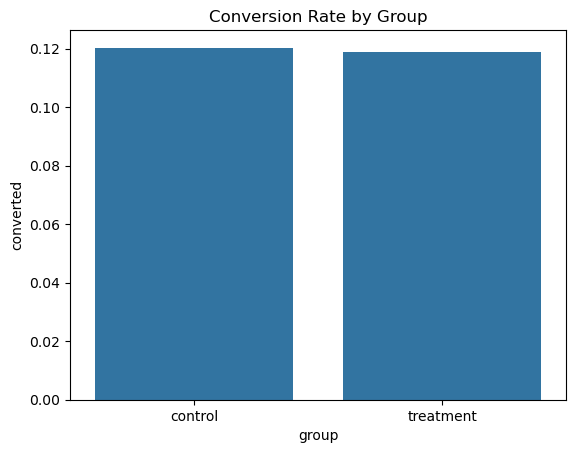

In [13]:
conversion = df.groupby("group")["converted"].mean().reset_index()

sns.barplot(x="group", y="converted", data=conversion)

plt.title("Conversion Rate by Group")
plt.show()

In [14]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]

success = [treatment.sum(), control.sum()]
total = [len(treatment), len(control)]

z_stat, p_value = proportions_ztest(success, total)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: -1.2083846739740718
P Value: 0.22689933216132785


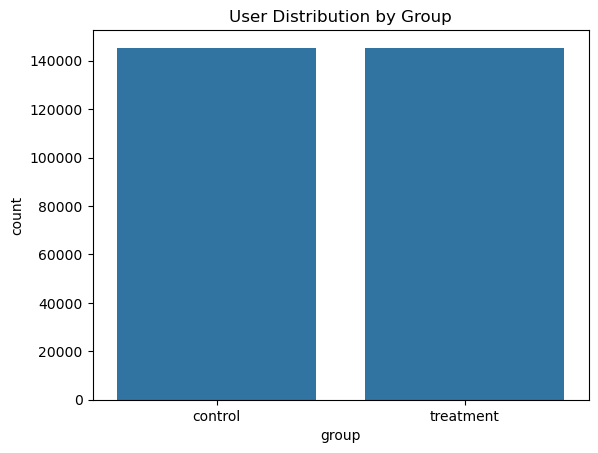

In [15]:
sns.countplot(x="group", data=df)

plt.title("User Distribution by Group")

plt.show()